# Customer Churn Prediction & Recommendation System

## Exploratory Data Analysis (EDA)

### Objectives

- Understand customer behavior
- Analyze churn distribution
- Explore relationships between variables
- Identify important business insights
- Prepare for feature engineering

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


### Import custom Module

In [2]:
import sys

sys.path.append("..")

from src.preprocessing.data_loader import load_data

### Load Clean Dataset

In [4]:
df = load_data("../data/processed/Telco_Customer_Churn_Cleaned.csv")

In [5]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Overall Customer Churn Distribution

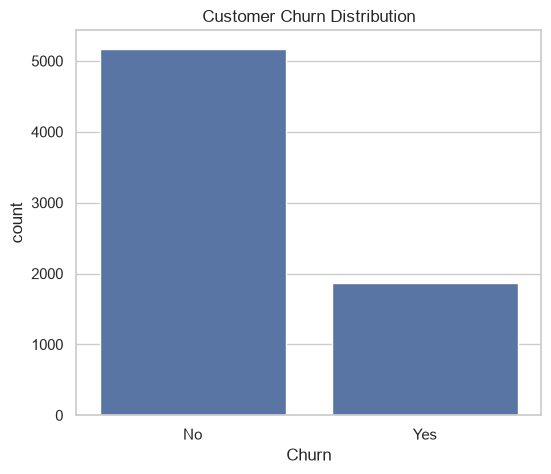

In [6]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.show()

In [7]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Insight

Approximately 26% of customers have churned.

This indicates that customer churn is a significant business issue.

### Gender Distibution

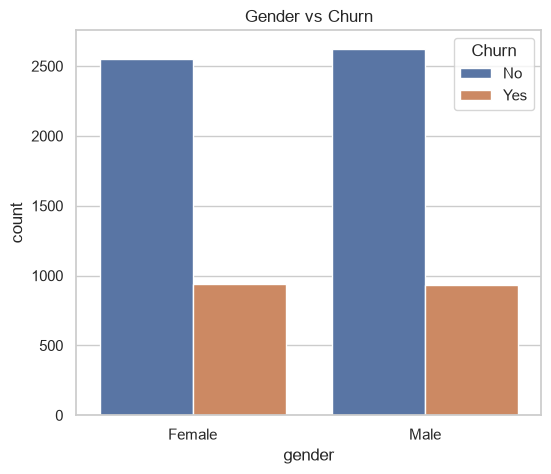

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

Male and female customers have similar churn behavior.

Gender alone may not be a strong predictor.

### Senior Citizen vs Churn

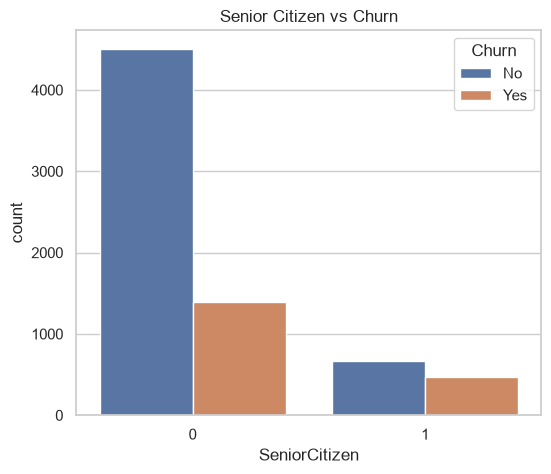

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()

### Contract Type vs Churn

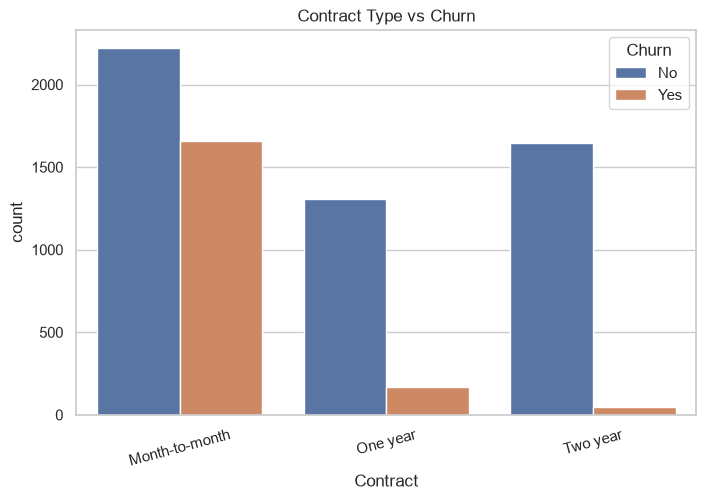

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

### Internet Service

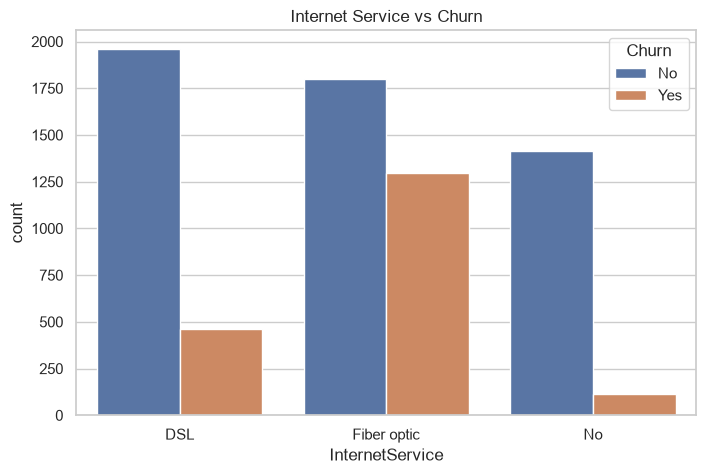

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

### Payment Method 

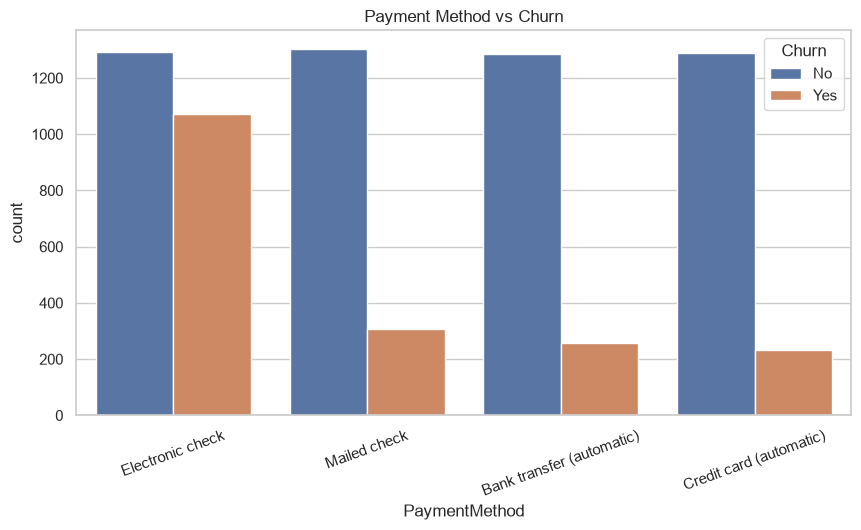

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

### Monthly Charges Distribution


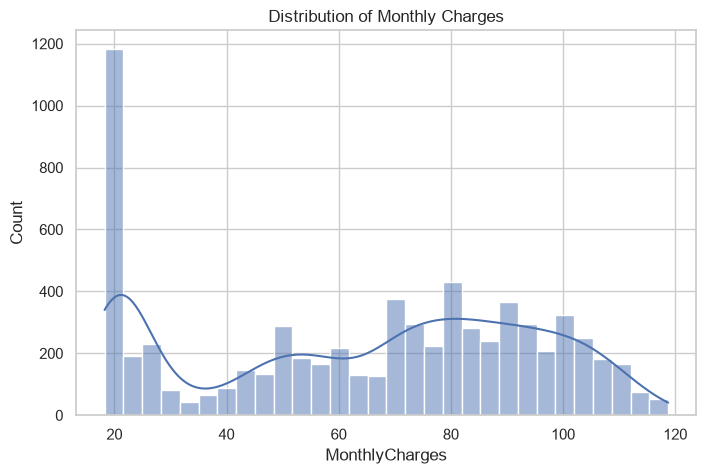

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")

plt.show()

### Monthly Charges VS Churn

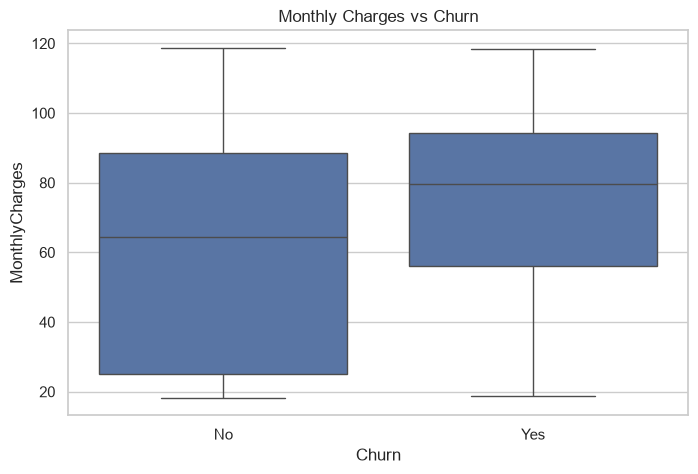

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

### Tenure Distribution

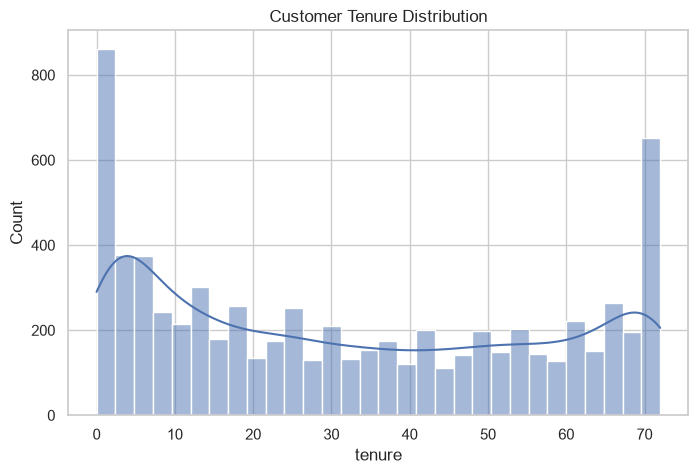

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

### Tenure VS churn

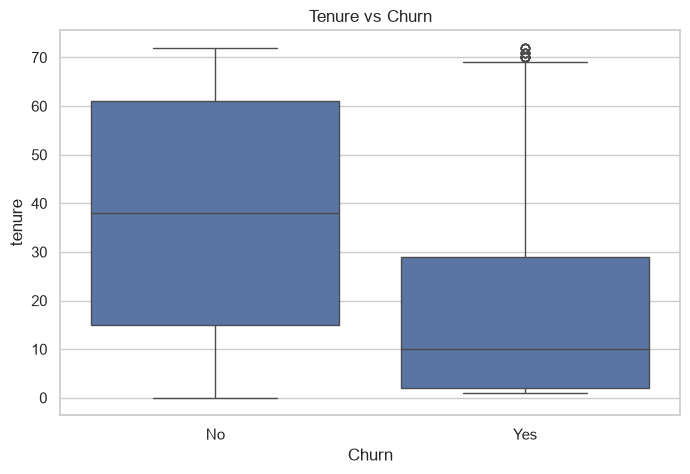

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")

plt.show()

## Correlation Heatmap
select only numeric columns:

In [17]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

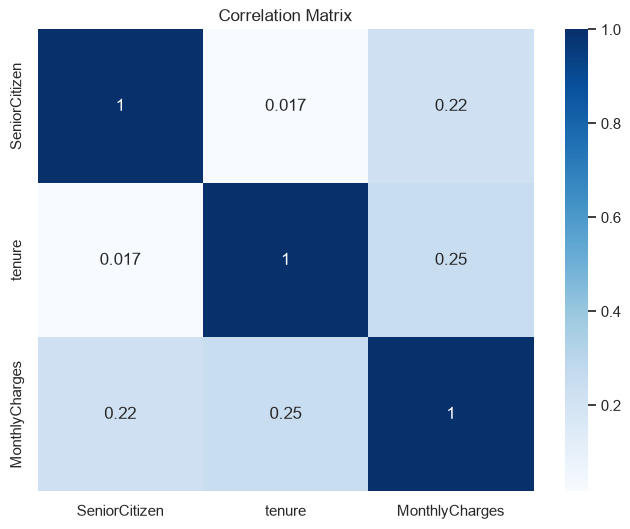

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()